# Experimenting with Savitzky Golay filter and Moving Average Filter

### Savitzky Golay Filter

In [ ]:
import numpy as np
import math

def savgol_filter(x, window_length, poly_order, deriv=0, dt=1.0):


    x = np.asarray(x, dtype=float)

    if window_length % 2 == 0:
        raise ValueError("window_length must be odd")

    if poly_order >= window_length:
        raise ValueError("poly_order must be smaller than window_length")

    if deriv > poly_order:
        raise ValueError("deriv must be <= poly_order")

    half_window = window_length // 2

    # Sample positions inside the window
    k = np.arange(-half_window, half_window + 1)

    # Polynomial design matrix
    # rows -> samples
    # columns -> 1, k, k^2, ..., k^poly_order
    A = np.vander(k, N=poly_order + 1, increasing=True)

    # Pseudoinverse
    A_inv = np.linalg.pinv(A)

    # SG coefficients
    coeffs = (
        A_inv[deriv]
        * math.factorial(deriv)
        / (dt ** deriv)
    )

    # Pad signal so output has same length as input
    x_padded = np.pad(x, half_window, mode="reflect")

    # Apply filter
    y = np.convolve(x_padded, coeffs[::-1], mode="valid")

    return y

## Moving Average Filter

In [ ]:
import numpy as np

def moving_average(x, window_length):

    x = np.asarray(x, dtype=float)

    if window_length < 1:
        raise ValueError("window_length must be positive")

    if window_length % 2 == 0:
        raise ValueError("window_length should be odd")

    half_window = window_length // 2

    # Pad to preserve signal length
    x_padded = np.pad(x, half_window, mode="reflect")

    # Moving-average kernel
    kernel = np.ones(window_length) / window_length

    # Filtering
    y = np.convolve(x_padded, kernel, mode="valid")

    return y

### Testing the Savitzky Golay Filter

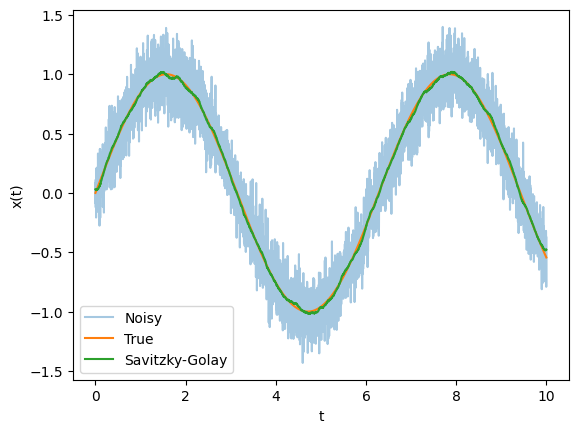

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

t = np.linspace(0, 10, 5000)
dt = t[1] - t[0]

x_clean = np.sin(t)
x = x_clean + 0.15 * np.random.randn(len(t))

x_smooth = savgol_filter(
    x,
    window_length=201,
    poly_order=3
)

plt.plot(t, x, alpha=0.4, label="Noisy")
plt.plot(t, x_clean, label="True")
plt.plot(t, x_smooth, label="Savitzky-Golay")
plt.xlabel("t")
plt.ylabel("x(t)")
plt.legend()
plt.show()

## Testing the moving average filter

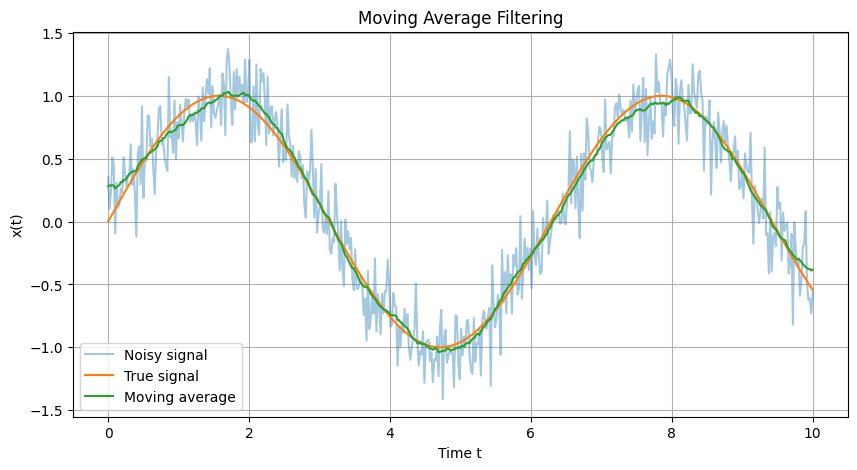

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data
np.random.seed(0)

t = np.linspace(0, 10, 500)

x_true = np.sin(t)
x_noisy = x_true + 0.2 * np.random.randn(len(t))

# Apply moving average
x_ma = moving_average(
    x_noisy,
    window_length=21
)

# Plot
plt.figure(figsize=(10, 5))

plt.plot(t, x_noisy, alpha=0.4, label="Noisy signal")
plt.plot(t, x_true, label="True signal")
plt.plot(t, x_ma, label="Moving average")

plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.title("Moving Average Filtering")
plt.legend()
plt.grid()

plt.show()

## Testing both filters on $\sin x$

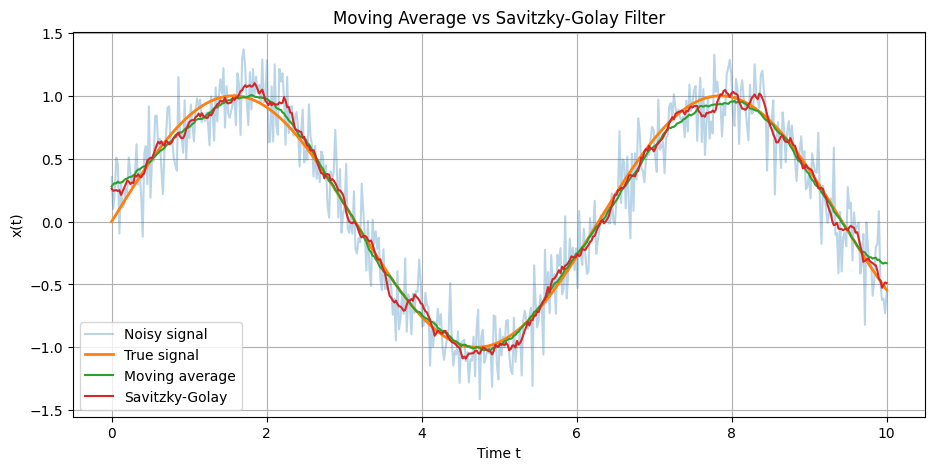

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# Generate data
np.random.seed(0)

t = np.linspace(0, 10, 500)
dt = t[1] - t[0]

x_true = np.sin(t)
x_noisy = x_true + 0.2 * np.random.randn(len(t))

# Moving average
x_ma = moving_average(
    x_noisy,
    window_length=41
)

# Savitzky-Golay
x_sg = savgol_filter(
    x_noisy,
    window_length=21,
    poly_order=3
)

# Plot
plt.figure(figsize=(11, 5))

plt.plot(t, x_noisy, alpha=0.3, label="Noisy signal")
plt.plot(t, x_true, linewidth=2, label="True signal")
plt.plot(t, x_ma, label="Moving average")
plt.plot(t, x_sg, label="Savitzky-Golay")

plt.xlabel("Time t")
plt.ylabel("x(t)")
plt.title("Moving Average vs Savitzky-Golay Filter")
plt.legend()
plt.grid()

plt.show()

### Comparing both with window size 21

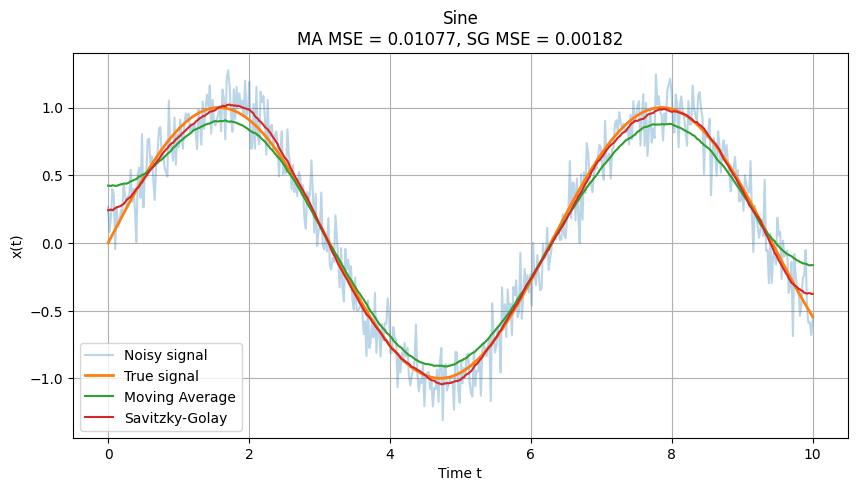

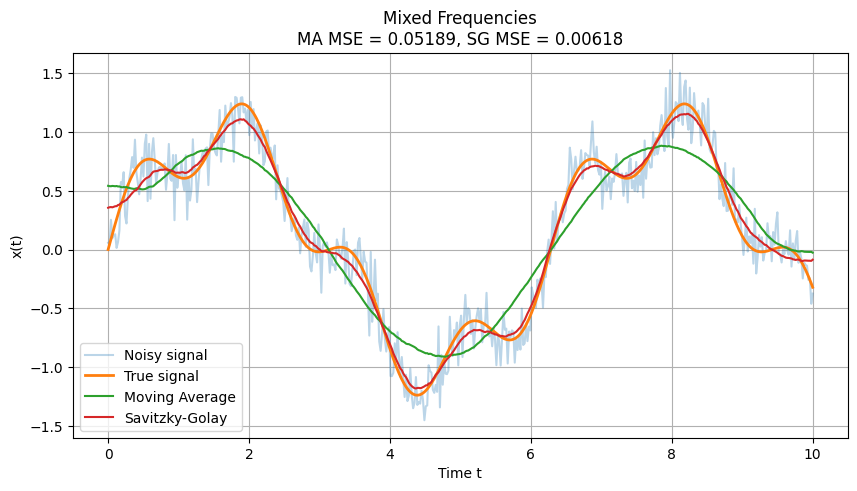

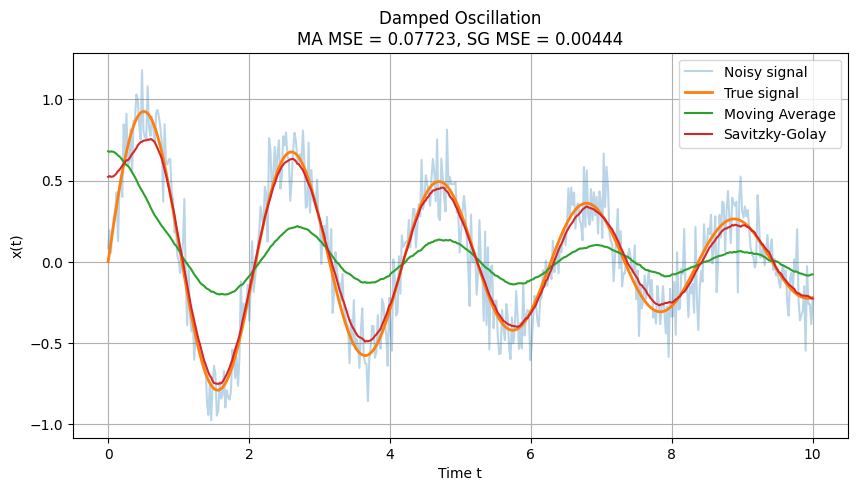

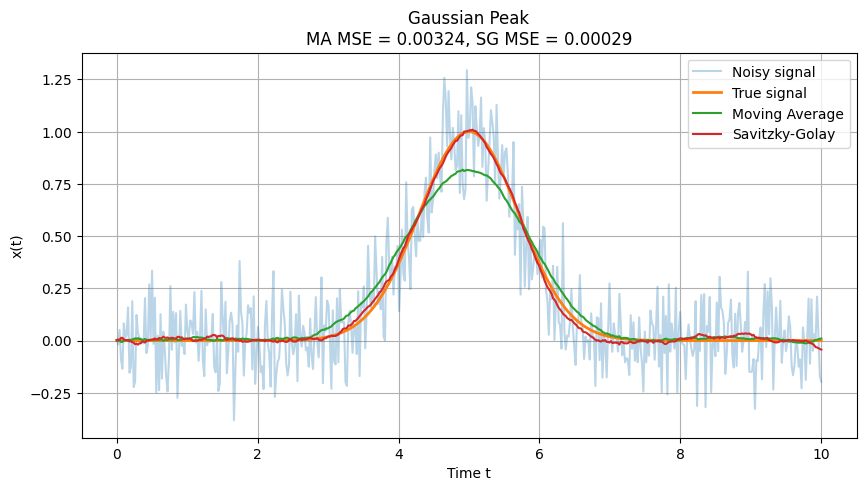

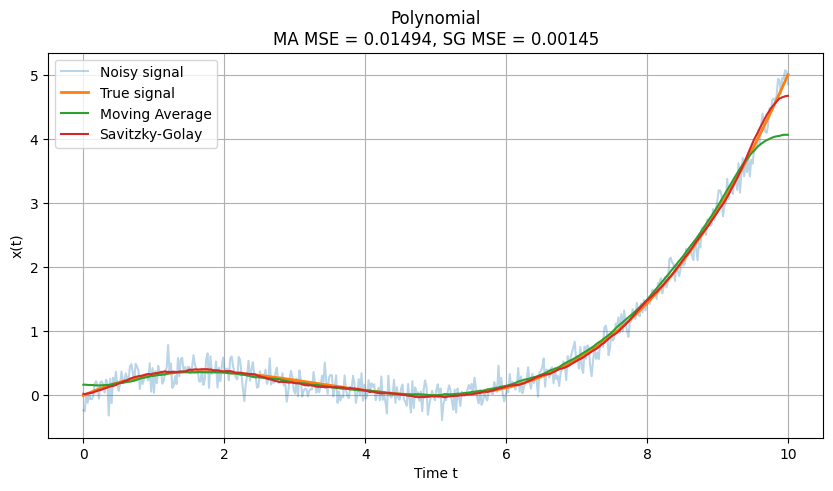

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def moving_average(x, window_length):
    x = np.asarray(x, dtype=float)

    if window_length % 2 == 0:
        raise ValueError("window_length must be odd")

    half_window = window_length // 2

    x_padded = np.pad(x, half_window, mode="reflect")

    kernel = np.ones(window_length) / window_length

    y = np.convolve(x_padded, kernel, mode="valid")

    return y


# Savitzky-Golay Filter
def savgol_filter(x, window_length, poly_order):
    x = np.asarray(x, dtype=float)

    if window_length % 2 == 0:
        raise ValueError("window_length must be odd")

    half_window = window_length // 2

    k = np.arange(-half_window, half_window + 1)

    A = np.vander(
        k,
        N=poly_order + 1,
        increasing=True
    )

    A_inv = np.linalg.pinv(A)

    # coefficients for smoothed value
    coeffs = A_inv[0]

    x_padded = np.pad(
        x,
        half_window,
        mode="reflect"
    )

    y = np.convolve(
        x_padded,
        coeffs[::-1],
        mode="valid"
    )

    return y


# Test setup

np.random.seed(0)

t = np.linspace(0, 10, 500)

noise_level = 0.15

window_length = 21
poly_order = 3


# Different test signals
signals = {

    "Sine":
        np.sin(t),

    "Mixed Frequencies":
        np.sin(t) + 0.3*np.sin(4*t),

    "Damped Oscillation":
        np.exp(-0.15*t) * np.sin(3*t),

    "Gaussian Peak":
        np.exp(-(t - 5)**2),

    "Polynomial":
        0.02*t**3 - 0.2*t**2 + 0.5*t
}


for name, x_true in signals.items():

    # Add noise
    x_noisy = (
        x_true
        + noise_level*np.random.randn(len(t))
    )

    # Apply filters
    x_ma = moving_average(
        x_noisy,
        window_length
    )

    x_sg = savgol_filter(
        x_noisy,
        window_length,
        poly_order
    )

    # Calculate MSE
    mse_ma = np.mean(
        (x_ma - x_true)**2
    )

    mse_sg = np.mean(
        (x_sg - x_true)**2
    )

    plt.figure(figsize=(10, 5))

    plt.plot(
        t,
        x_noisy,
        alpha=0.3,
        label="Noisy signal"
    )

    plt.plot(
        t,
        x_true,
        linewidth=2,
        label="True signal"
    )

    plt.plot(
        t,
        x_ma,
        label="Moving Average"
    )

    plt.plot(
        t,
        x_sg,
        label="Savitzky-Golay"
    )

    plt.xlabel("Time t")
    plt.ylabel("x(t)")

    plt.title(
        f"{name}\n"
        f"MA MSE = {mse_ma:.5f}, "
        f"SG MSE = {mse_sg:.5f}"
    )

    plt.legend()
    plt.grid()

    plt.show()

### Comparing both with window size 81

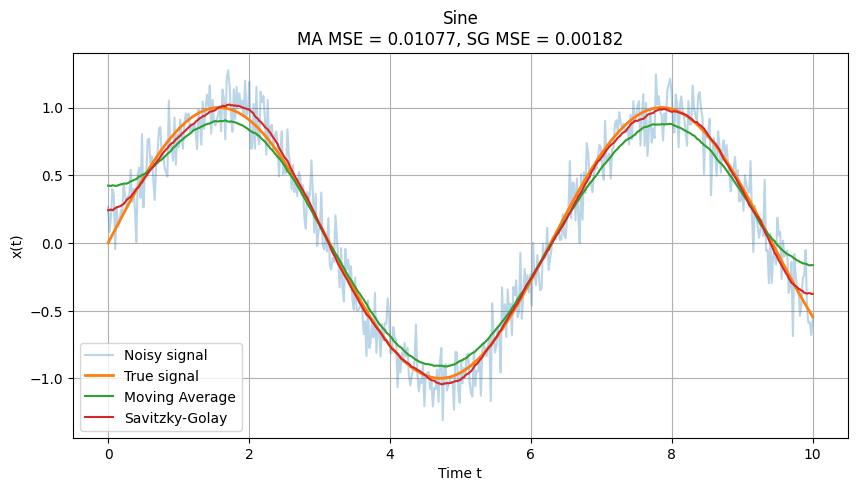

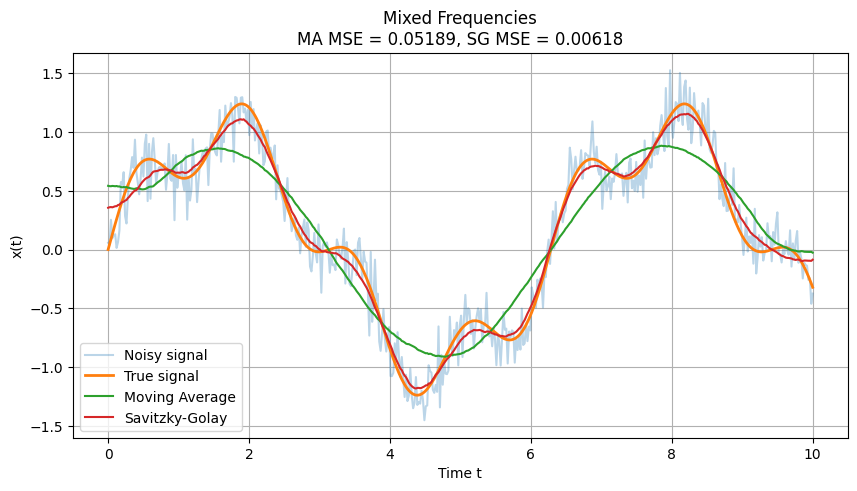

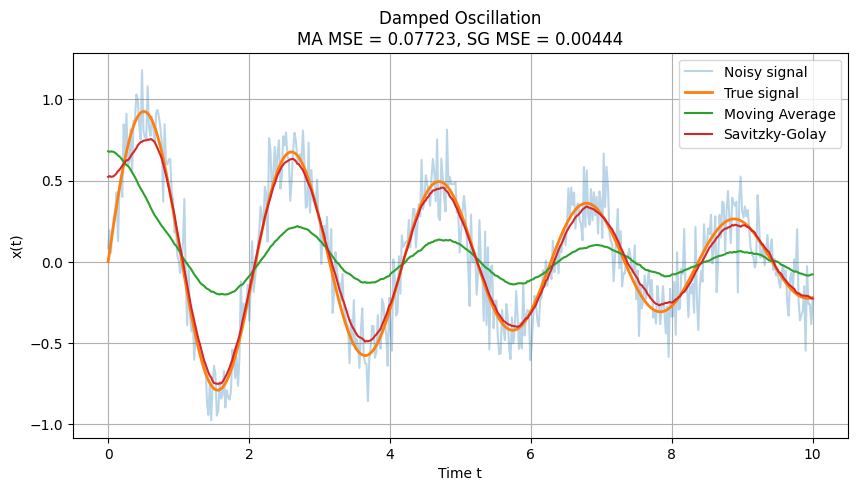

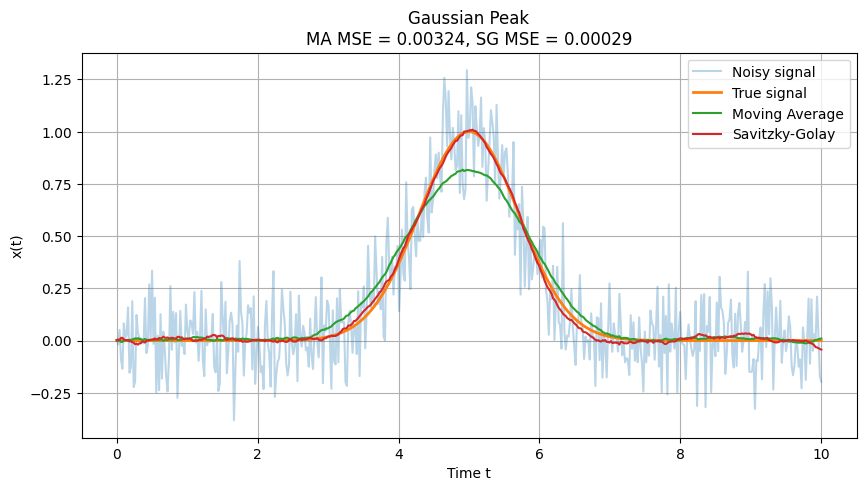

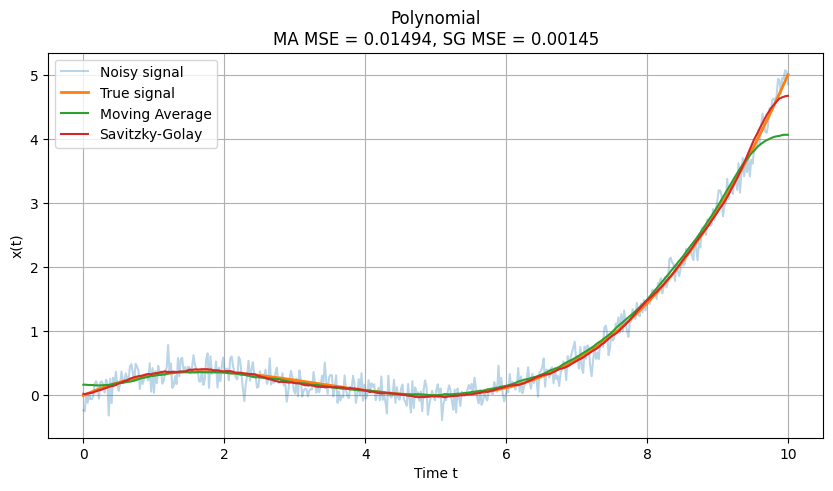

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# --------------------------------------------------
# Moving Average Filter
# --------------------------------------------------
def moving_average(x, window_length):
    x = np.asarray(x, dtype=float)

    if window_length % 2 == 0:
        raise ValueError("window_length must be odd")

    half_window = window_length // 2

    x_padded = np.pad(x, half_window, mode="reflect")

    kernel = np.ones(window_length) / window_length

    y = np.convolve(x_padded, kernel, mode="valid")

    return y


# --------------------------------------------------
# Savitzky-Golay Filter
# --------------------------------------------------
def savgol_filter(x, window_length, poly_order):
    x = np.asarray(x, dtype=float)

    if window_length % 2 == 0:
        raise ValueError("window_length must be odd")

    half_window = window_length // 2

    k = np.arange(-half_window, half_window + 1)

    A = np.vander(
        k,
        N=poly_order + 1,
        increasing=True
    )

    A_inv = np.linalg.pinv(A)

    # coefficients for smoothed value
    coeffs = A_inv[0]

    x_padded = np.pad(
        x,
        half_window,
        mode="reflect"
    )

    y = np.convolve(
        x_padded,
        coeffs[::-1],
        mode="valid"
    )

    return y


# --------------------------------------------------
# Test setup
# --------------------------------------------------
np.random.seed(0)

t = np.linspace(0, 10, 500)

noise_level = 0.15

window_length = 81
poly_order = 2


# --------------------------------------------------
# Different test signals
# --------------------------------------------------
signals = {

    "Sine":
        np.sin(t),

    "Mixed Frequencies":
        np.sin(t) + 0.3*np.sin(4*t),

    "Damped Oscillation":
        np.exp(-0.15*t) * np.sin(3*t),

    "Gaussian Peak":
        np.exp(-(t - 5)**2),

    "Polynomial":
        0.02*t**3 - 0.2*t**2 + 0.5*t
}


# --------------------------------------------------
# Test each signal
# --------------------------------------------------
for name, x_true in signals.items():

    # Add noise
    x_noisy = (
        x_true
        + noise_level*np.random.randn(len(t))
    )

    # Apply filters
    x_ma = moving_average(
        x_noisy,
        window_length
    )

    x_sg = savgol_filter(
        x_noisy,
        window_length,
        poly_order
    )

    # Calculate MSE
    mse_ma = np.mean(
        (x_ma - x_true)**2
    )

    mse_sg = np.mean(
        (x_sg - x_true)**2
    )

    # --------------------------------------------------
    # Plot
    # --------------------------------------------------
    plt.figure(figsize=(10, 5))

    plt.plot(
        t,
        x_noisy,
        alpha=0.3,
        label="Noisy signal"
    )

    plt.plot(
        t,
        x_true,
        linewidth=2,
        label="True signal"
    )

    plt.plot(
        t,
        x_ma,
        label="Moving Average"
    )

    plt.plot(
        t,
        x_sg,
        label="Savitzky-Golay"
    )

    plt.xlabel("Time t")
    plt.ylabel("x(t)")

    plt.title(
        f"{name}\n"
        f"MA MSE = {mse_ma:.5f}, "
        f"SG MSE = {mse_sg:.5f}"
    )

    plt.legend()
    plt.grid()

    plt.show()

### Derivatives with Window size 21 order 3

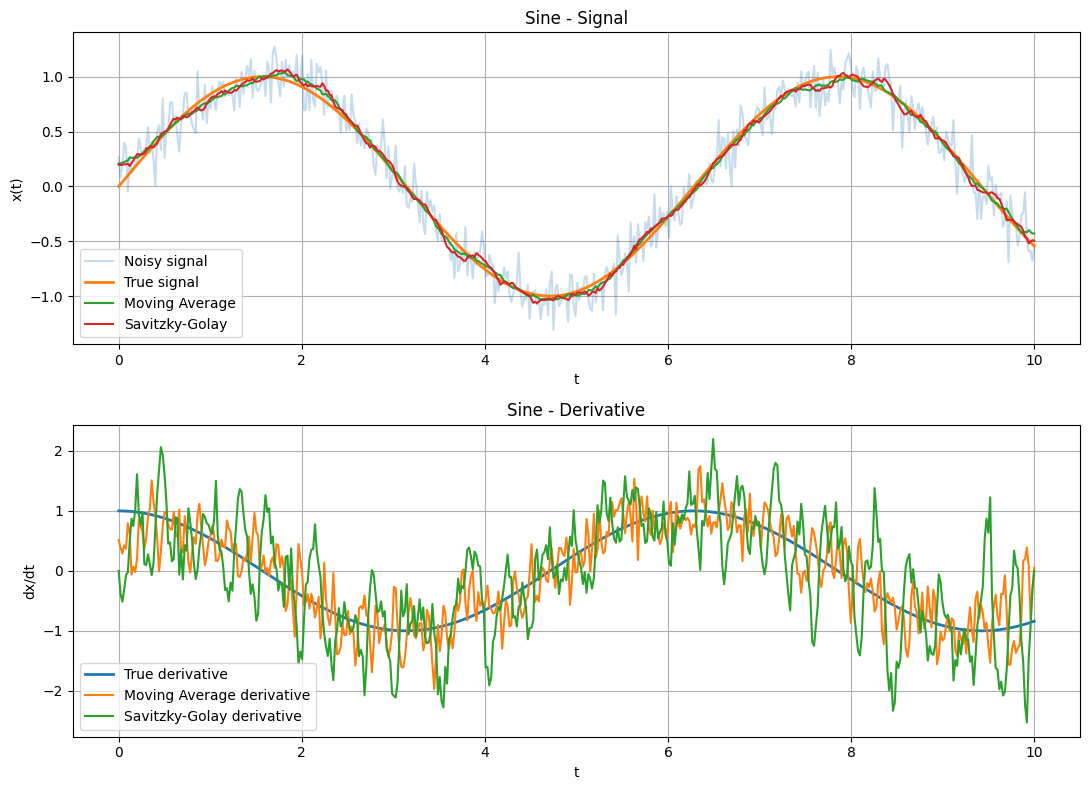

Sine
Moving Average derivative MSE: 0.12244327436314015
Savitzky-Golay derivative MSE: 0.3982945888949975
-----------------------------------


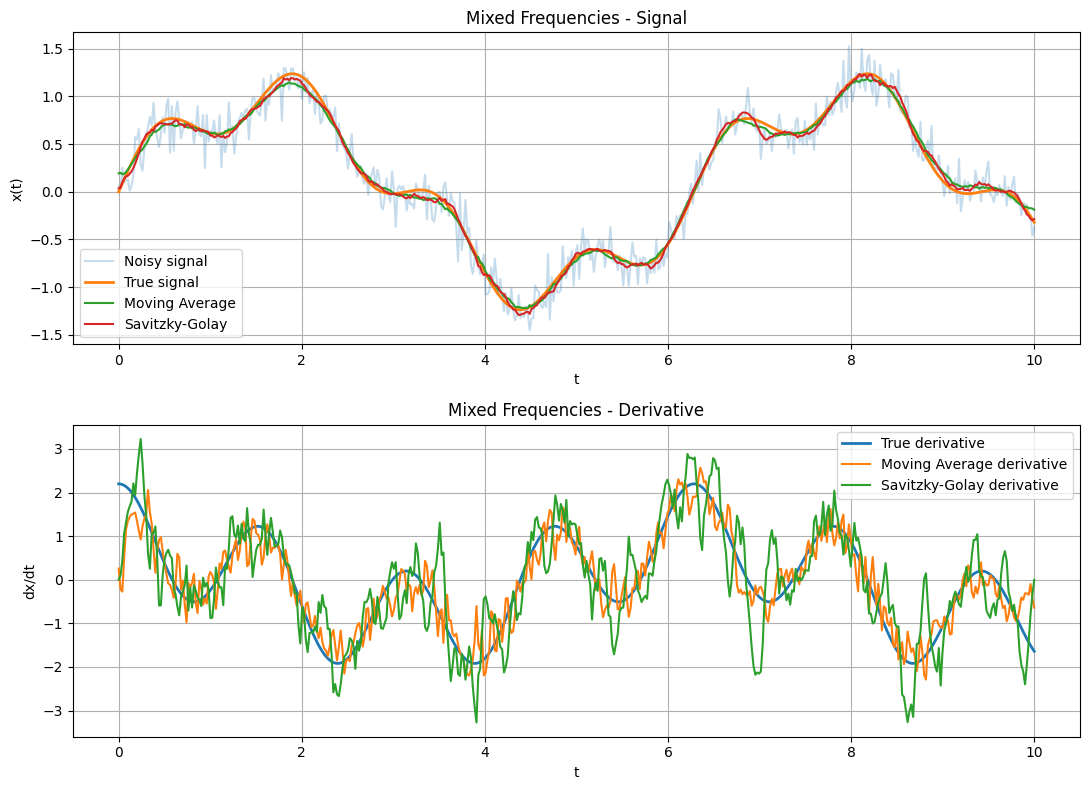

Mixed Frequencies
Moving Average derivative MSE: 0.12423731080442012
Savitzky-Golay derivative MSE: 0.41324004825552074
-----------------------------------


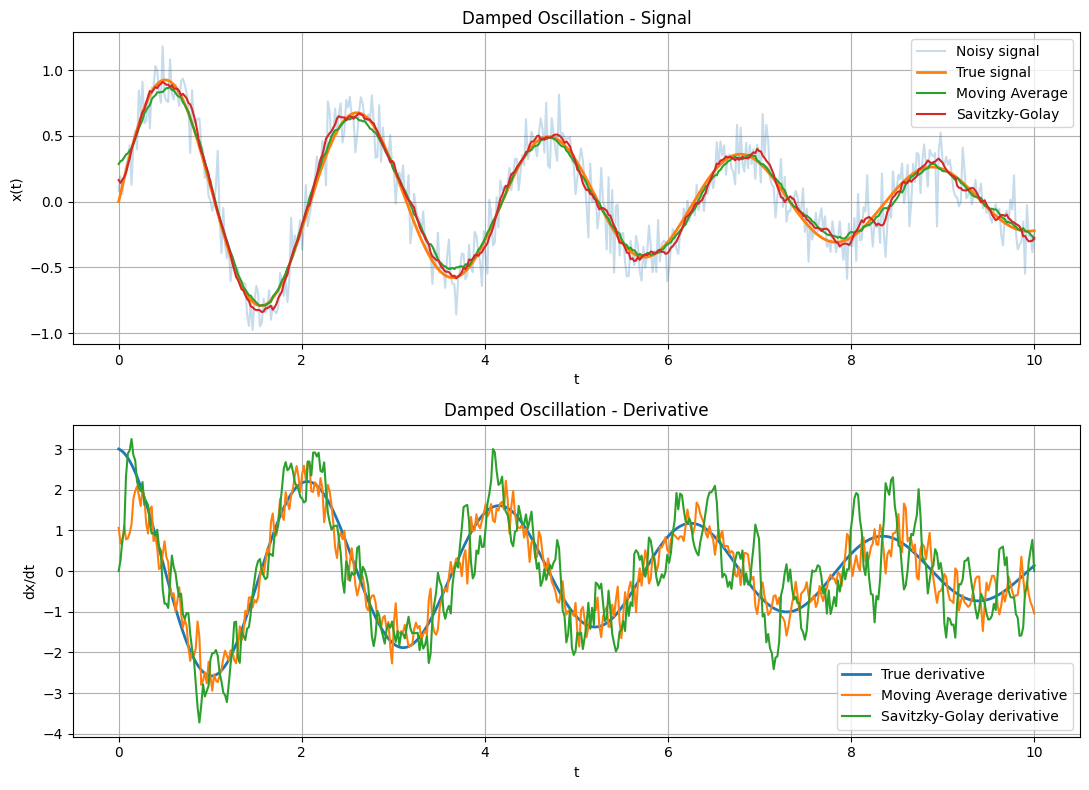

Damped Oscillation
Moving Average derivative MSE: 0.11327491388391667
Savitzky-Golay derivative MSE: 0.41003509784017567
-----------------------------------


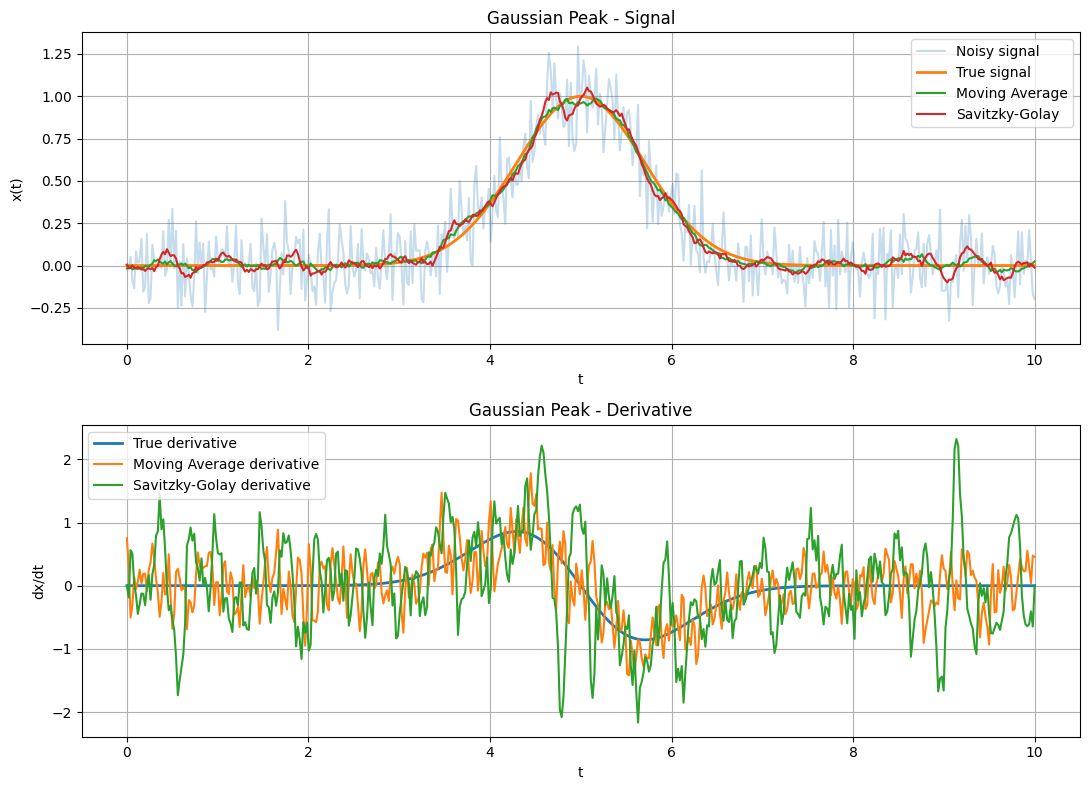

Gaussian Peak
Moving Average derivative MSE: 0.12053108502170072
Savitzky-Golay derivative MSE: 0.42945072281534113
-----------------------------------


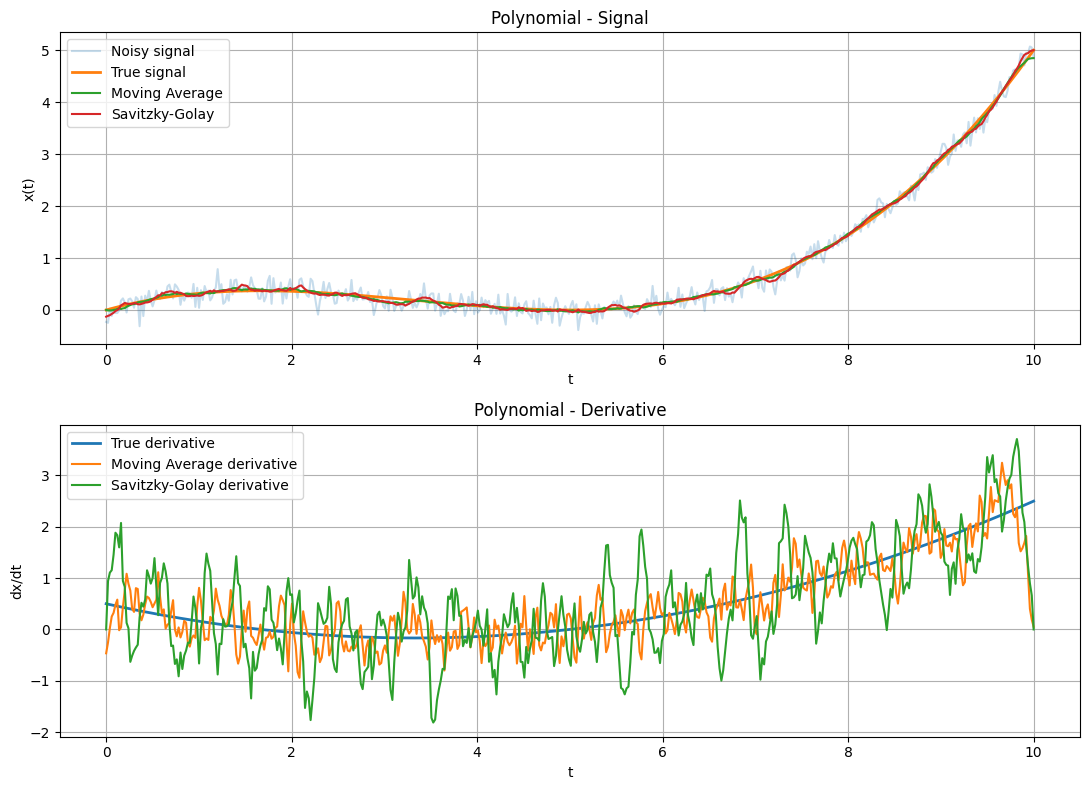

Polynomial
Moving Average derivative MSE: 0.11999881692232055
Savitzky-Golay derivative MSE: 0.4727898053085474
-----------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math


# Moving Average Filter

def moving_average(x, window_length):

    x = np.asarray(x, dtype=float)

    if window_length % 2 == 0:
        raise ValueError("window_length must be odd")

    half_window = window_length // 2

    x_padded = np.pad(
        x,
        half_window,
        mode="reflect"
    )

    kernel = np.ones(window_length) / window_length

    y = np.convolve(
        x_padded,
        kernel,
        mode="valid"
    )

    return y


# Savitzky-Golay Filter
def savgol_filter(x, window_length, poly_order, deriv=0, dt=1.0):

    x = np.asarray(x, dtype=float)

    if window_length % 2 == 0:
        raise ValueError("window_length must be odd")

    if poly_order >= window_length:
        raise ValueError("poly_order must be smaller than window_length")

    half_window = window_length // 2

    # Local sample positions
    k = np.arange(
        -half_window,
        half_window + 1
    )

    # Polynomial design matrix
    A = np.vander(
        k,
        N=poly_order + 1,
        increasing=True
    )

    A_inv = np.linalg.pinv(A)

    # SG coefficients
    coeffs = (
        A_inv[deriv]
        * math.factorial(deriv)
        / (dt**deriv)
    )

    x_padded = np.pad(
        x,
        half_window,
        mode="reflect"
    )

    y = np.convolve(
        x_padded,
        coeffs[::-1],
        mode="valid"
    )

    return y


# Time
np.random.seed(0)

t = np.linspace(0, 10, 500)

dt = t[1] - t[0]

noise_level = 0.15

window_length = 21
poly_order = 3


# Signals AND their exact derivatives
signals = {

    "Sine":
    (
        np.sin(t),

        np.cos(t)
    ),

    "Mixed Frequencies":
    (
        np.sin(t) + 0.3*np.sin(4*t),

        np.cos(t) + 1.2*np.cos(4*t)
    ),

    "Damped Oscillation":
    (
        np.exp(-0.15*t)*np.sin(3*t),

        np.exp(-0.15*t) *
        (
            3*np.cos(3*t)
            - 0.15*np.sin(3*t)
        )
    ),

    "Gaussian Peak":
    (
        np.exp(-(t - 5)**2),

        -2*(t - 5)
        * np.exp(-(t - 5)**2)
    ),

    "Polynomial":
    (
        0.02*t**3
        - 0.2*t**2
        + 0.5*t,

        0.06*t**2
        - 0.4*t
        + 0.5
    )
}


# Test all signals
for name, (x_true, dx_true) in signals.items():

    # Add noise
    x_noisy = (
        x_true
        + noise_level*np.random.randn(len(t))
    )


    # Moving Average
    x_ma = moving_average(
        x_noisy,
        window_length
    )

    # Differentiate the smoothed MA signal
    dx_ma = np.gradient(
        x_ma,
        dt
    )


    # Savitzky-Golay

    # Smoothed signal
    x_sg = savgol_filter(
        x_noisy,
        window_length,
        poly_order,
        deriv=0,
        dt=dt
    )

    # Direct SG derivative
    dx_sg = savgol_filter(
        x_noisy,
        window_length,
        poly_order,
        deriv=1,
        dt=dt
    )


    # Plot
    fig, ax = plt.subplots(
        2,
        1,
        figsize=(11, 8)
    )


    # Original signals
    ax[0].plot(
        t,
        x_noisy,
        alpha=0.25,
        label="Noisy signal"
    )

    ax[0].plot(
        t,
        x_true,
        linewidth=2,
        label="True signal"
    )

    ax[0].plot(
        t,
        x_ma,
        label="Moving Average"
    )

    ax[0].plot(
        t,
        x_sg,
        label="Savitzky-Golay"
    )

    ax[0].set_title(
        name + " - Signal"
    )

    ax[0].set_xlabel("t")
    ax[0].set_ylabel("x(t)")
    ax[0].legend()
    ax[0].grid()


    # Derivatives
    ax[1].plot(
        t,
        dx_true,
        linewidth=2,
        label="True derivative"
    )

    ax[1].plot(
        t,
        dx_ma,
        label="Moving Average derivative"
    )

    ax[1].plot(
        t,
        dx_sg,
        label="Savitzky-Golay derivative"
    )

    ax[1].set_title(
        name + " - Derivative"
    )

    ax[1].set_xlabel("t")
    ax[1].set_ylabel("dx/dt")
    ax[1].legend()
    ax[1].grid()

    plt.tight_layout()
    plt.show()


    # Derivative MSE

    # Ignore edges because padding causes boundary effects
    edge = window_length // 2

    mse_ma = np.mean(
        (
            dx_ma[edge:-edge]
            - dx_true[edge:-edge]
        )**2
    )

    mse_sg = np.mean(
        (
            dx_sg[edge:-edge]
            - dx_true[edge:-edge]
        )**2
    )

    print(name)

    print(
        "Moving Average derivative MSE:",
        mse_ma
    )

    print(
        "Savitzky-Golay derivative MSE:",
        mse_sg
    )

    print("-----------------------------------")

### Derivatives with Window Size 81, order 3

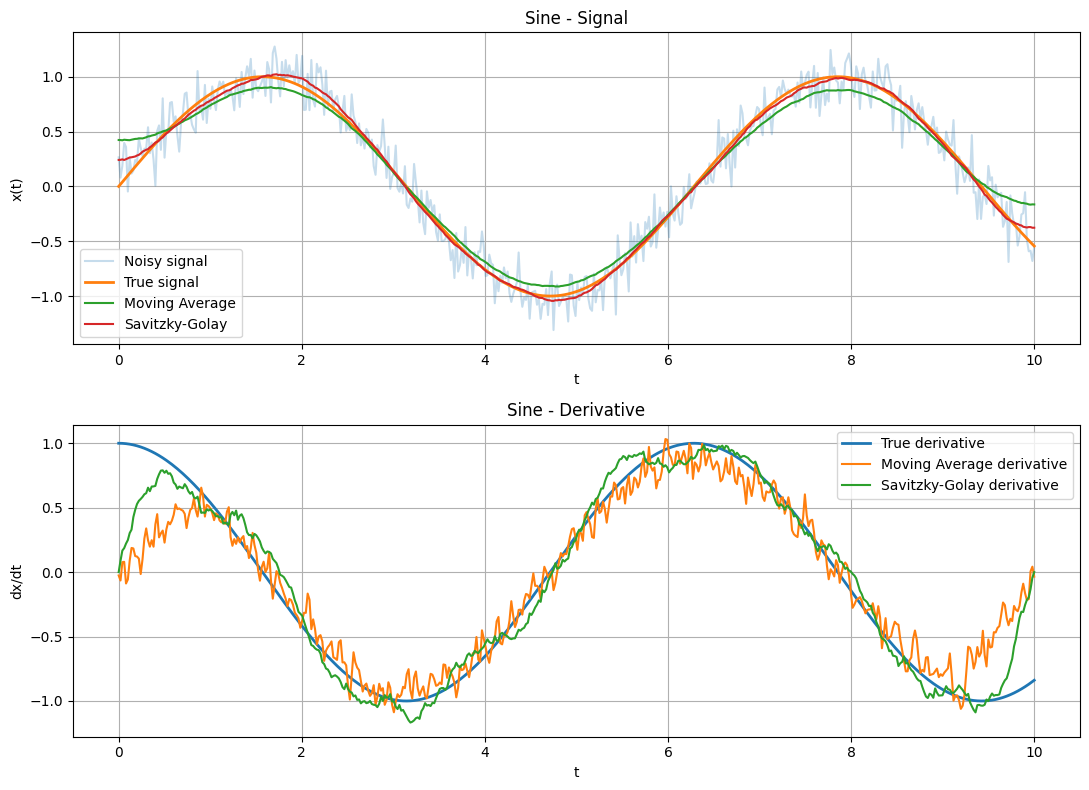

Sine
Moving Average derivative MSE: 0.012160277704605945
Savitzky-Golay derivative MSE: 0.010083236229330918
-----------------------------------


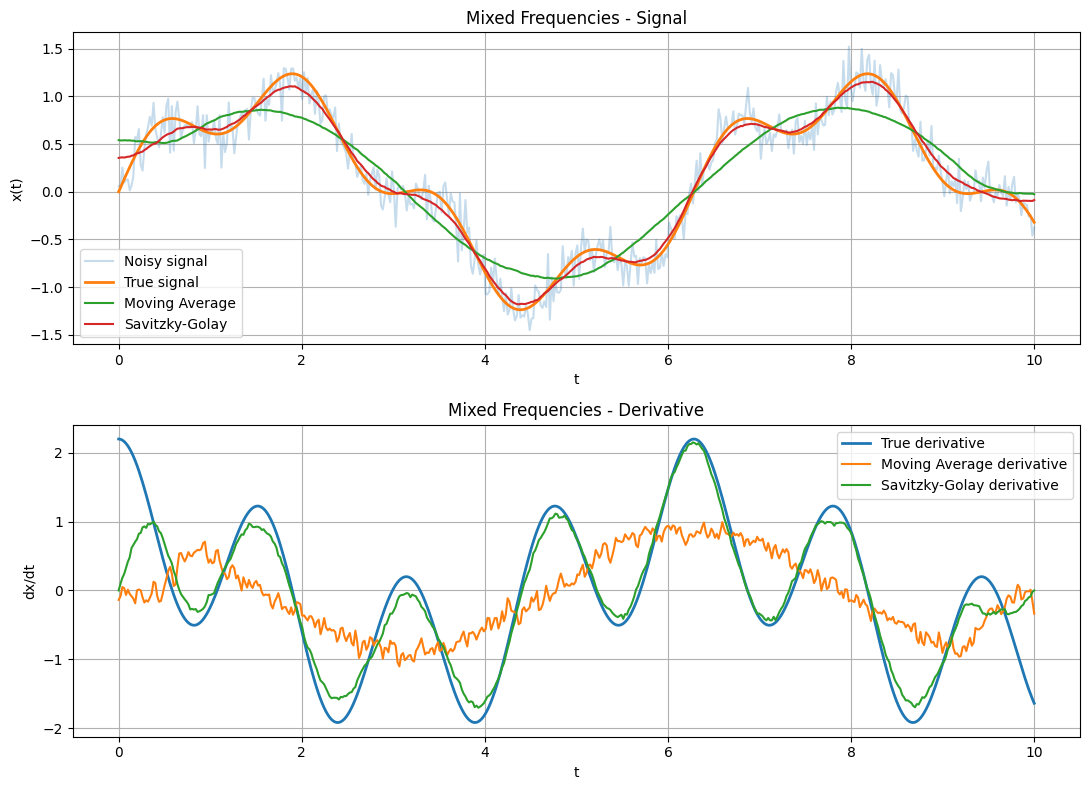

Mixed Frequencies
Moving Average derivative MSE: 0.7729139590705018
Savitzky-Golay derivative MSE: 0.02893059875639516
-----------------------------------


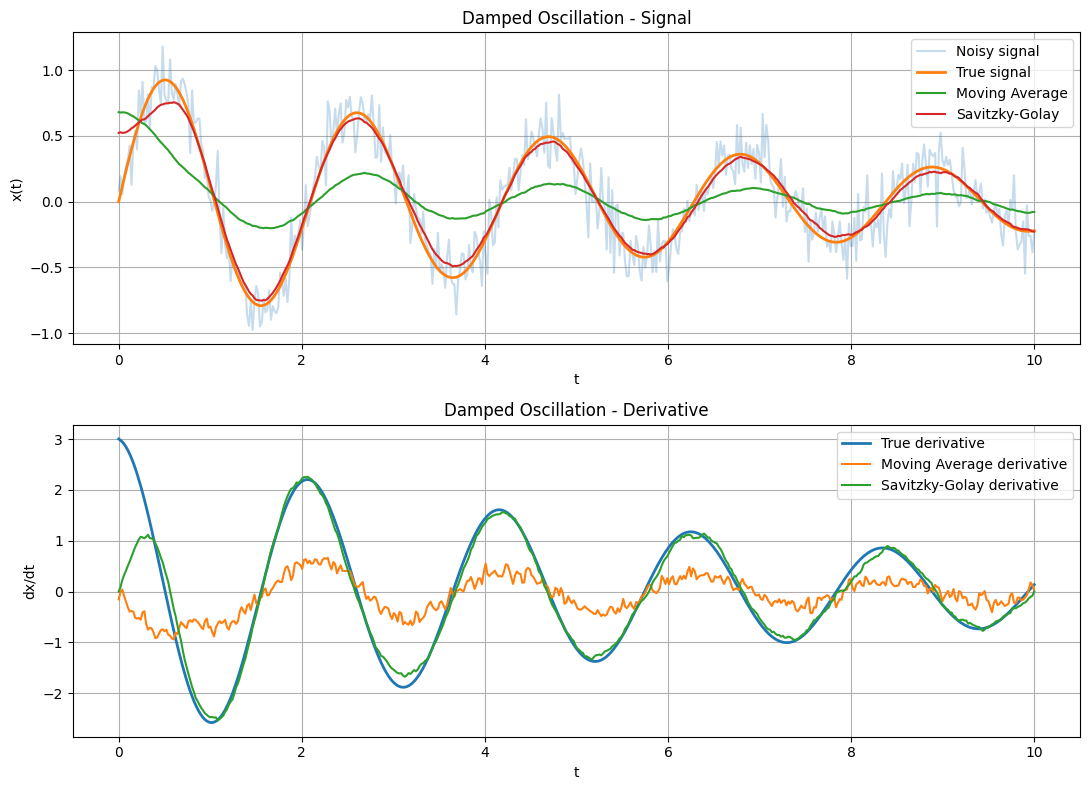

Damped Oscillation
Moving Average derivative MSE: 0.7368854162494642
Savitzky-Golay derivative MSE: 0.011739762089342704
-----------------------------------


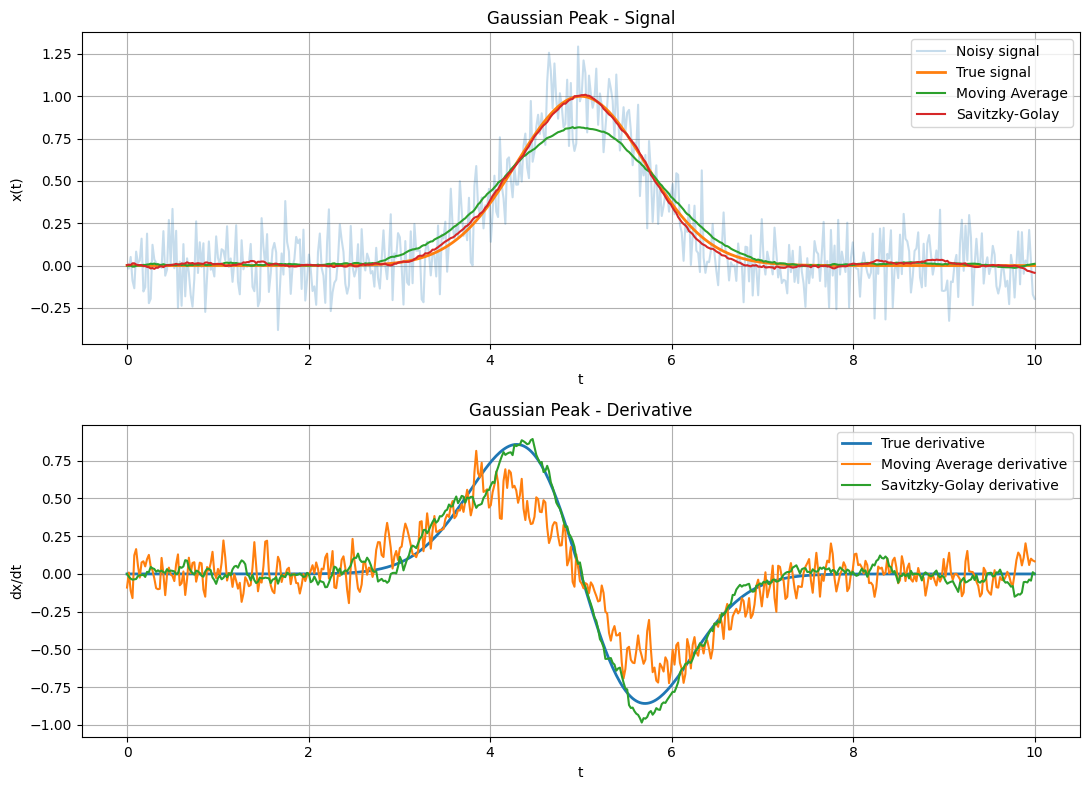

Gaussian Peak
Moving Average derivative MSE: 0.023933180093276243
Savitzky-Golay derivative MSE: 0.00325183153428016
-----------------------------------


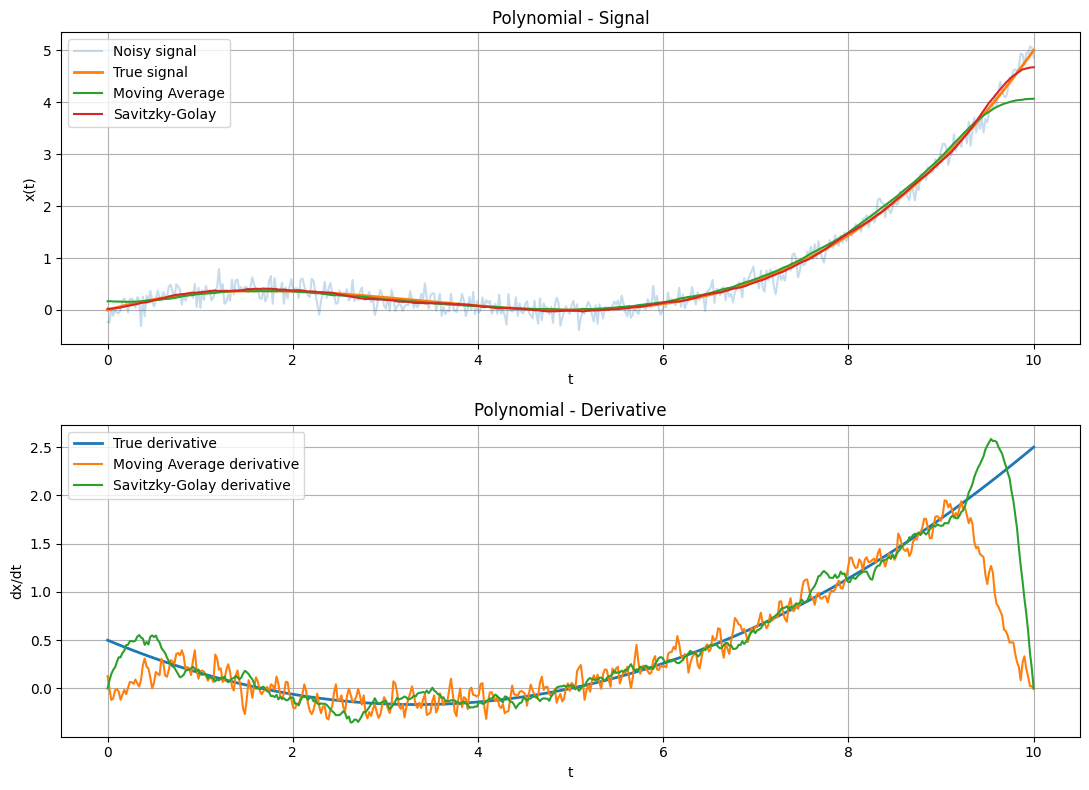

Polynomial
Moving Average derivative MSE: 0.00880583260852347
Savitzky-Golay derivative MSE: 0.004739357533771253
-----------------------------------


In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import math


# Moving Average Filter
def moving_average(x, window_length):

    x = np.asarray(x, dtype=float)

    if window_length % 2 == 0:
        raise ValueError("window_length must be odd")

    half_window = window_length // 2

    x_padded = np.pad(
        x,
        half_window,
        mode="reflect"
    )

    kernel = np.ones(window_length) / window_length

    y = np.convolve(
        x_padded,
        kernel,
        mode="valid"
    )

    return y


# Savitzky-Golay Filter
def savgol_filter(x, window_length, poly_order, deriv=0, dt=1.0):

    x = np.asarray(x, dtype=float)

    if window_length % 2 == 0:
        raise ValueError("window_length must be odd")

    if poly_order >= window_length:
        raise ValueError("poly_order must be smaller than window_length")

    half_window = window_length // 2

    # Local sample positions
    k = np.arange(
        -half_window,
        half_window + 1
    )

    # Polynomial design matrix
    A = np.vander(
        k,
        N=poly_order + 1,
        increasing=True
    )

    A_inv = np.linalg.pinv(A)

    # SG coefficients
    coeffs = (
        A_inv[deriv]
        * math.factorial(deriv)
        / (dt**deriv)
    )

    x_padded = np.pad(
        x,
        half_window,
        mode="reflect"
    )

    y = np.convolve(
        x_padded,
        coeffs[::-1],
        mode="valid"
    )

    return y


# Time
np.random.seed(0)

t = np.linspace(0, 10, 500)

dt = t[1] - t[0]

noise_level = 0.15

window_length = 81
poly_order = 3


# Signals AND their exact derivatives
signals = {

    "Sine":
    (
        np.sin(t),

        np.cos(t)
    ),

    "Mixed Frequencies":
    (
        np.sin(t) + 0.3*np.sin(4*t),

        np.cos(t) + 1.2*np.cos(4*t)
    ),

    "Damped Oscillation":
    (
        np.exp(-0.15*t)*np.sin(3*t),

        np.exp(-0.15*t) *
        (
            3*np.cos(3*t)
            - 0.15*np.sin(3*t)
        )
    ),

    "Gaussian Peak":
    (
        np.exp(-(t - 5)**2),

        -2*(t - 5)
        * np.exp(-(t - 5)**2)
    ),

    "Polynomial":
    (
        0.02*t**3
        - 0.2*t**2
        + 0.5*t,

        0.06*t**2
        - 0.4*t
        + 0.5
    )
}


# Test all signals
for name, (x_true, dx_true) in signals.items():

    # Add noise
    x_noisy = (
        x_true
        + noise_level*np.random.randn(len(t))
    )


    # Moving Average
    x_ma = moving_average(
        x_noisy,
        window_length
    )

    # Differentiate the smoothed MA signal
    dx_ma = np.gradient(
        x_ma,
        dt
    )


    # Savitzky-Golay

    # Smoothed signal
    x_sg = savgol_filter(
        x_noisy,
        window_length,
        poly_order,
        deriv=0,
        dt=dt
    )

    # Direct SG derivative
    dx_sg = savgol_filter(
        x_noisy,
        window_length,
        poly_order,
        deriv=1,
        dt=dt
    )


    # Plot
    fig, ax = plt.subplots(
        2,
        1,
        figsize=(11, 8)
    )


    # Original signals
    ax[0].plot(
        t,
        x_noisy,
        alpha=0.25,
        label="Noisy signal"
    )

    ax[0].plot(
        t,
        x_true,
        linewidth=2,
        label="True signal"
    )

    ax[0].plot(
        t,
        x_ma,
        label="Moving Average"
    )

    ax[0].plot(
        t,
        x_sg,
        label="Savitzky-Golay"
    )

    ax[0].set_title(
        name + " - Signal"
    )

    ax[0].set_xlabel("t")
    ax[0].set_ylabel("x(t)")
    ax[0].legend()
    ax[0].grid()


    # Derivatives
    ax[1].plot(
        t,
        dx_true,
        linewidth=2,
        label="True derivative"
    )

    ax[1].plot(
        t,
        dx_ma,
        label="Moving Average derivative"
    )

    ax[1].plot(
        t,
        dx_sg,
        label="Savitzky-Golay derivative"
    )

    ax[1].set_title(
        name + " - Derivative"
    )

    ax[1].set_xlabel("t")
    ax[1].set_ylabel("dx/dt")
    ax[1].legend()
    ax[1].grid()

    plt.tight_layout()
    plt.show()


    # Derivative MSE

    # Ignore edges because padding causes boundary effects
    edge = window_length // 2

    mse_ma = np.mean(
        (
            dx_ma[edge:-edge]
            - dx_true[edge:-edge]
        )**2
    )

    mse_sg = np.mean(
        (
            dx_sg[edge:-edge]
            - dx_true[edge:-edge]
        )**2
    )

    print(name)

    print(
        "Moving Average derivative MSE:",
        mse_ma
    )

    print(
        "Savitzky-Golay derivative MSE:",
        mse_sg
    )

    print("-----------------------------------")